In [1]:
!pip install yfinance pandas numpy scipy matplotlib seaborn dtaidistance scikit-learn statsmodels

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score, calinski_harabasz_score,davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller, coint
from dtaidistance import dtw
import warnings
warnings.filterwarnings('ignore')

In [3]:
# --- Configuration ---
BENCHMARK = '^IXIC'
RISK_FREE_RATE = 0.045
START_DATE = '2014-01-01'
END_DATE = '2024-01-01'
ROLLING_WINDOW = 52
N_CLUSTERS = [2, 4, 7]  # Target number of clusters
MIN_HISTORY = 400 # Minimum weeks of data required per stock

In [4]:
# Retrieving NASDAQ tickers (100)
nasdaq_100_tickers = [
    'AAPL', 'MSFT', 'NVDA', 'AMZN', 'META', 'TSLA', 'GOOGL', 'GOOG', 'AVGO', 'ASML',
    'COST', 'NFLX', 'AZN', 'AMD', 'PEP', 'ADBE', 'LIN', 'QCOM', 'INTU', 'AMAT',
    'CSCO', 'TXN', 'AMGN', 'ISRG', 'MU', 'HON', 'BKNG', 'VRTX', 'REGN', 'ADI',
    'PANW', 'LRCX', 'GILD', 'SBUX', 'MDLZ', 'ADP', 'KLAC', 'MELI', 'SNPS', 'CDNS',
    'CRWD', 'ABNB', 'MAR', 'ORLY', 'CTAS', 'MNST', 'FTNT', 'WDAY', 'MRVL', 'PCAR',
    'CPRT', 'ROST', 'PAYX', 'DXCM', 'KDP', 'ODFL', 'FAST', 'IDXX', 'MCHP', 'BIIB',
    'EA', 'GEHC', 'EXC', 'KHC', 'VRSK', 'ON', 'XEL', 'CTSH', 'DLTR', 'CCEP',
    'CSGP', 'ANSS', 'FANG', 'BKR', 'CDW', 'TEAM', 'DDOG', 'SMCI', 'ILMN', 'WBD',
    'ZS', 'ALGN', 'ENPH', 'GFS', 'MDB', 'LCID', 'RIVN', 'SIRI', 'MTCH', 'PARA'
]

# Downloading benchmark data
print('Downloading NASDAQ benchmark data...')
benchmark_raw = yf.download(BENCHMARK, start=START_DATE, end=END_DATE, interval='1wk')
benchmark_prices = benchmark_raw['Close'].squeeze()
benchmark_returns = np.log(benchmark_prices / benchmark_prices.shift(1)).dropna()

print(f'Benchmark data downloaded: {len(benchmark_returns)} weekly observations')
print(f'Date range: {benchmark_returns.index[0].date()} to {benchmark_returns.index[-1].date()}')

[*********************100%***********************]  1 of 1 completed

Benchmark data downloaded: 521 weekly observations
Date range: 2014-01-08 to 2023-12-27


In [6]:
# Downloading all stock price data
print(f'Downloading price data for {len(nasdaq_100_tickers)} stocks...')

raw_data = yf.download(
    nasdaq_100_tickers,
    start=START_DATE,
    end=END_DATE,
    interval='1wk',
    auto_adjust=True,
    progress=True
)

# Extracting closing prices
price_data = raw_data['Close']

# Dropping stocks with insufficient history
valid_stocks = price_data.columns[price_data.count() >= MIN_HISTORY].tolist()
price_data = price_data[valid_stocks]

# Fill any small gaps, then drop any remaining NaNs
price_data = price_data.ffill().dropna(axis=1)

# Resampling to weekly frequency anchored on Wednesdays
price_data = price_data.resample('W-WED').last()
price_data = price_data.dropna(how='all')
valid_stocks = price_data.columns[price_data.count() >= MIN_HISTORY].tolist()
price_data = price_data[valid_stocks]
price_data = price_data.ffill().dropna(axis=1)


print(f'\nStocks with sufficient history: {len(price_data.columns)}')
print(f'Date range: {price_data.index[0].date()} to {price_data.index[-1].date()}')
print(f'Total weekly observations per stocks: {len(price_data)}')

print(price_data.shape)

[**                     4%                       ]  4 of 90 completed$PARA: possibly delisted; no timezone found
$ANSS: possibly delisted; no timezone found      ]  67 of 90 completed
[*********************100%***********************]  90 of 90 completed

2 Failed downloads:
['PARA', 'ANSS']: possibly delisted; no timezone found



Stocks with sufficient history: 77
Date range: 2014-01-01 to 2023-12-27
Total weekly observations per stocks: 522
(522, 77)


In [7]:
# Calculate Log Returns for all stocks and benchmarks
stock_returns = np.log(price_data / price_data.shift(1)).dropna()

# Align benchmark returns to match stock return dates exactly 
benchmark_returns_aligned = benchmark_returns.reindex(stock_returns.index).ffill().dropna()

# Making both the same date range
common_dates = stock_returns.index.intersection(benchmark_returns_aligned.index)
stock_returns = stock_returns.loc[common_dates]
benchmark_returns_aligned = benchmark_returns_aligned.loc[common_dates]

print(f'Stock returns shape: {stock_returns.shape}')
print(f'Benchmark returns shape: {benchmark_returns_aligned.shape}')
print(f'Date range: {stock_returns.index[0].date()} to {stock_returns.index[-1].date()}')
print(f'\nSample returns for AAPL (first 5 weeks):')
print(stock_returns['AAPL'].head())

Stock returns shape: (521, 77)
Benchmark returns shape: (521,)
Date range: 2014-01-08 to 2023-12-27

Sample returns for AAPL (first 5 weeks):
Date
2014-01-08    0.011690
2014-01-15    0.004893
2014-01-22   -0.080702
2014-01-29    0.004511
2014-02-05    0.052024
Freq: W-WED, Name: AAPL, dtype: float64


In [10]:
# Calculating Rolling Sharpe Ratio for each stock
def calculate_rolling_sharpe(stock_returns, risk_free_rate=RISK_FREE_RATE, window=ROLLING_WINDOW):
    """
    Sharpe Ratio = (Annualized Return - Risk Free Rate) / Annualized Volatility
    """

    # Converting annual risk free rate to weekly
    weekly_rf = risk_free_rate / 52

    # Calculating excess returns over risk free rate
    excess_returns = stock_returns.subtract(weekly_rf)

    # Calculating rolling annulaized mean excess return (Sharpe Ratio - numerator)
    rolling_mean = excess_returns.rolling(window=window).mean() * window 

    # Calculating rolling annualized volatilty (Sharpe Ratio - denominator)
    rolling_vol = stock_returns.rolling(window=window).std() * np.sqrt(window)

    # Sharpe Ratio
    sharpe = rolling_mean / rolling_vol

    return sharpe

# Running the Calculation
print("Calculating rolling Sharpe Ratios...")
sharpe_data = calculate_rolling_sharpe(stock_returns)

# Dropping the first 52 rows where rolling windows is not full yet
sharpe_data = sharpe_data.dropna(how='all')

# Dropping any stocks that still have NaN values
sharpe_data = sharpe_data.dropna(axis=1)

print(f"Sharpe Ratio matrix shape: {sharpe_data.shape}")
print(f"Date range: {sharpe_data.index[0].date()} to {sharpe_data.index[-1].date()}")
print(f"Stocks remaining: {len(sharpe_data.columns)}")
print(f"\nSample Sharpe Ratio for AAPL (first 5 values):")
print(sharpe_data['AAPL'].head())

Calculating rolling Sharpe Ratios...
Sharpe Ratio matrix shape: (470, 77)
Date range: 2014-12-31 to 2023-12-27
Stocks remaining: 77

Sample Sharpe Ratio for AAPL (first 5 values):
Date
2014-12-31    1.206897
2015-01-07    1.298953
2015-01-14    1.219418
2015-01-21    1.671935
2015-01-28    1.915245
Freq: W-WED, Name: AAPL, dtype: float64


In [12]:
# Building DTW Distance Matrix
print('Building DTW distance matrix...')
print('This is the most computationally expensive step, so it may take 5-10 minutes...')
n = len(sharpe_data.columns)
print(f'Computing {n} x {n} distance matrix\n')

# Convert Sharpe data to Numpy array
sharpe_matrix = sharpe_data.values.T # Transpose so shape is (n_stocks, n_timepoints)

# Normalizing each stock's IR series to have a mean of 0 and std of 1
scaler = StandardScaler()
sharpe_matrix_scaled = scaler.fit_transform(sharpe_matrix.T).T

# Computing DTW distance matrix
n_stocks = sharpe_matrix_scaled.shape[0]
distance_matrix_sharpe = np.zeros((n_stocks, n_stocks))

for i in range(n_stocks):
    for j in range(i+1, n_stocks):
        dist = dtw.distance(sharpe_matrix_scaled[i], sharpe_matrix_scaled[j])
        distance_matrix_sharpe[i, j] = dist
        distance_matrix_sharpe[j, i] = dist

    if i % 10 == 0:
        print(f'Progress: {i}/{n_stocks} stocks processed...')

print(f'\nDTW distance matrix complete!')
print(f'Distance matrix shape: {distance_matrix_sharpe.shape}')
print(f'Sample distances (first 3x3):')
print(np.round(distance_matrix[:3,:3], 4))

# Saving
np.save('distance_matrix_sharpe.npy', distance_matrix_sharpe)
print("\nDistance matrix saved to distance_matrix_sharpe.npy")

Building DTW distance matrix...
This is the most computationally expensive step, so it may take 5-10 minutes...
Computing 77 x 77 distance matrix

Progress: 0/77 stocks processed...
Progress: 10/77 stocks processed...
Progress: 20/77 stocks processed...
Progress: 30/77 stocks processed...
Progress: 40/77 stocks processed...
Progress: 50/77 stocks processed...
Progress: 60/77 stocks processed...
Progress: 70/77 stocks processed...

DTW distance matrix complete!
Distance matrix shape: (77, 77)
Sample distances (first 3x3):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Distance matrix saved to distance_matrix_sharpe.npy


In [13]:
print("Sharpe matrix scaled shape:", sharpe_matrix_scaled.shape)
print("Any NaN values:", np.isnan(sharpe_matrix_scaled).any())
print("Any zero rows:", (sharpe_matrix_scaled == 0).all(axis=1).any())
print("Sample values (first stock, first 5 timepoints):")
print(sharpe_matrix_scaled[0, :5])
print("\nDistance matrix non-zero count:", np.count_nonzero(distance_matrix_sharpe))
print("Distance matrix max value:", distance_matrix_sharpe.max())

Sharpe matrix scaled shape: (77, 470)
Any NaN values: False
Any zero rows: False
Sample values (first stock, first 5 timepoints):
[0.4661764  0.56321252 0.47937451 0.95637431 1.21284747]

Distance matrix non-zero count: 5852
Distance matrix max value: 26.08806878651249


In [19]:
# Running Hierarchical Clustering for all k values 
print("Running hierarchical clustering...")

# Convert distance matrix to condensed form
condensed_distances = squareform(distance_matrix_sharpe)

# Building linkage matrix (same tree, different cuts)
linkage_matrix = linkage(condensed_distances, method="ward")

# Storing cluster assignements for each k
all_cluster_assignments = {}
all_cluster_sizes = {}

for k in N_CLUSTERS:
    labels = fcluster(linkage_matrix, t=k, criterion='maxclust')

    # Mapping to tickers
    assignments = pd.Series(labels, index=sharpe_data.columns, name='Cluster')
    all_cluster_assignments[k] = assignments

    # Cluster sizes
    sizes = assignments.value_counts().sort_index()
    all_cluster_sizes = sizes

    print(f'\nk={k} cluster sizes:')
    for cluster_num, size in sizes.items():
        print(f' Cluster {cluster_num}: {size} stocks')

print("\nClustering complete for all k values")


Running hierarchical clustering...

k=2 cluster sizes:
 Cluster 1: 38 stocks
 Cluster 2: 39 stocks

k=4 cluster sizes:
 Cluster 1: 38 stocks
 Cluster 2: 11 stocks
 Cluster 3: 11 stocks
 Cluster 4: 17 stocks

k=7 cluster sizes:
 Cluster 1: 21 stocks
 Cluster 2: 7 stocks
 Cluster 3: 10 stocks
 Cluster 4: 11 stocks
 Cluster 5: 11 stocks
 Cluster 6: 3 stocks
 Cluster 7: 14 stocks

Clustering complete for all k values


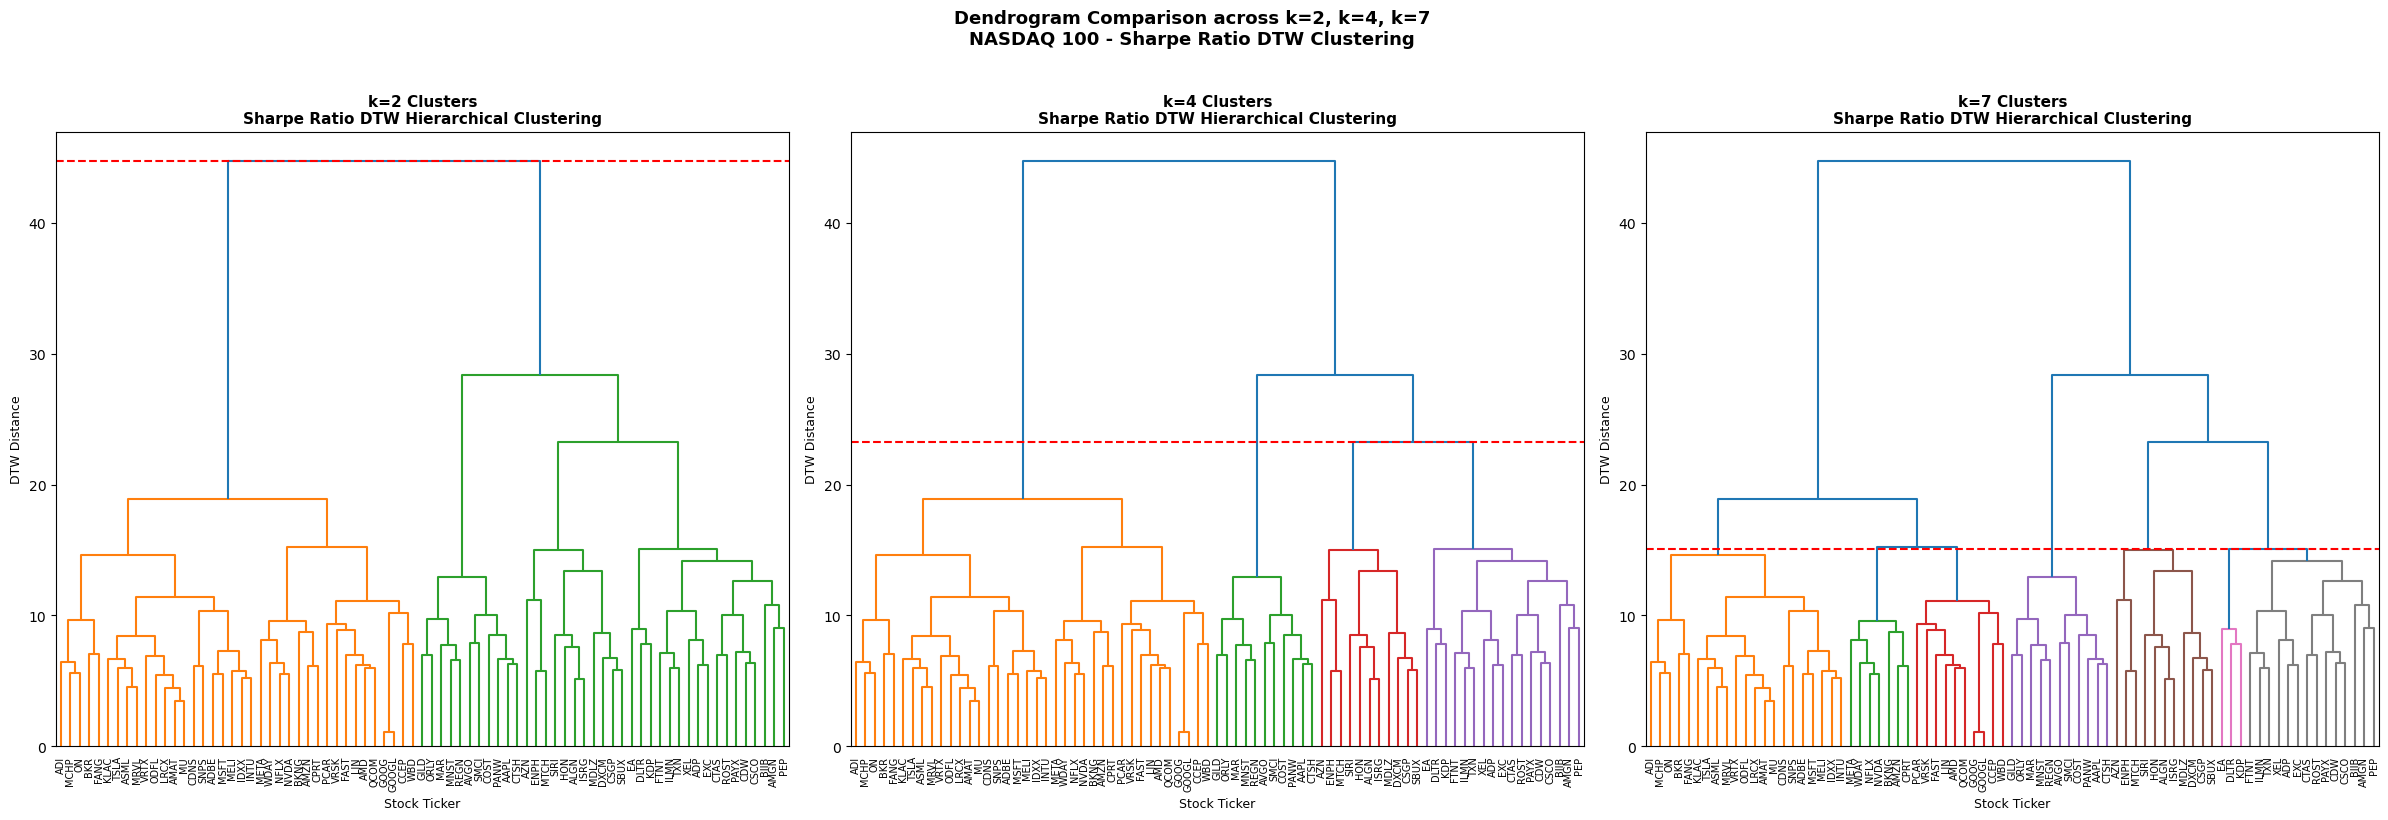

Dendrograms saved to dendrograms_comparison.png


In [21]:
# Visualizing Dendrograms for all k values
fig, axes = plt.subplots(1, 3, figsize=(24,8))

for idx, k in enumerate(N_CLUSTERS):
    color_threshold = linkage_matrix[-(k-1), 2]

    dendrogram(
        linkage_matrix,
        labels = sharpe_data.columns.tolist(),
        leaf_rotation = 90,
        leaf_font_size=7,
        color_threshold=color_threshold,
        ax=axes[idx]
    )

    axes[idx].set_title(
        f'k={k} Clusters\nSharpe Ratio DTW Hierarchical Clustering',
        fontsize=11,
        fontweight='bold'
    )
    axes[idx].set_xlabel('Stock Ticker', fontsize=9)
    axes[idx].set_ylabel('DTW Distance', fontsize=9)
    axes[idx].axhline(
        y=color_threshold,
        color='red',
        linestyle='--',
        linewidth=1.5,
        label=f'Cut at k={k}'
    )

plt.suptitle(
    'Dendrogram Comparison across k=2, k=4, k=7 \nNASDAQ 100 - Sharpe Ratio DTW Clustering ',
    fontsize=13,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.savefig('dendrograms_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Dendrograms saved to dendrograms_comparison.png')

Calculating Cluster Validation Indices...
Testing k=2 through k=7 to validate optimal cluster number

k=2: Silhouette=0.0829 CH=8.04 DB=2.9928
k=3: Silhouette=0.0693 CH=5.95 DB=2.9802
k=4: Silhouette=0.0533 CH=4.60 DB=3.4863
k=5: Silhouette=0.0167 CH=4.18 DB=3.4776
k=6: Silhouette=0.0105 CH=3.92 DB=3.1262
k=7: Silhouette=0.0110 CH=3.70 DB=2.9837


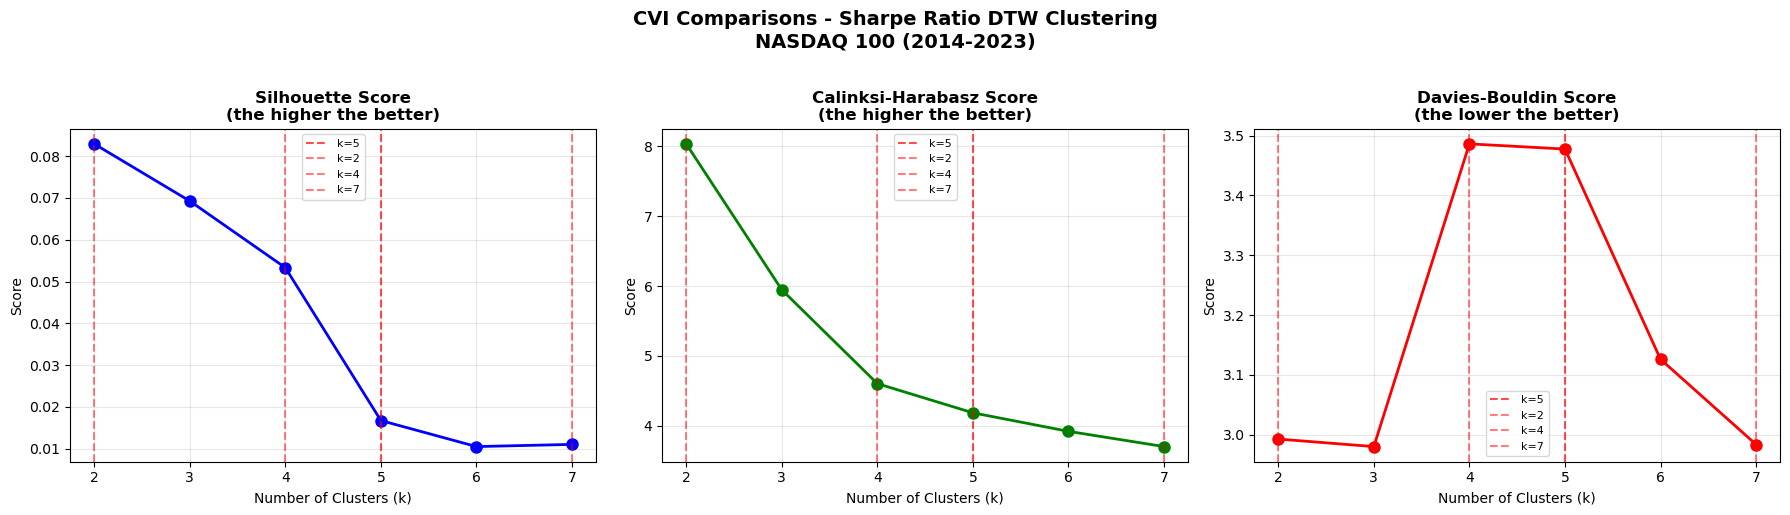


Best k by Silhouette: k=2
Best k by CH index: k=2
Best k by DB index: k=3


In [22]:
# CLuster Validation Indices (CVI's)
print('Calculating Cluster Validation Indices...')
print('Testing k=2 through k=7 to validate optimal cluster number\n')

X = sharpe_matrix_scaled

k_range = range(2,8)
silhouette_scores = []
ch_scores = []
db_scores = []

for k in k_range:
    # Getting cluster labels for this k
    labels = fcluster(linkage_matrix, t=k, criterion='maxclust')

    # Silhouette Score - The higher the better
    sil = silhouette_score(X, labels, metric='euclidean')
    silhouette_scores.append(sil)

    # CH Score - the higher the better
    ch = calinski_harabasz_score(X, labels)
    ch_scores.append(ch)

    # DB Score - the lower the better
    db = davies_bouldin_score(X, labels)
    db_scores.append(db)

    print(f'k={k}: Silhouette={sil:.4f} CH={ch:.2f} DB={db:.4f}')

# Plotting the CVI's
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Silhouette
axes[0].plot(list(k_range),  silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Silhouette Score\n(the higher the better)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Score')
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='k=5')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Calinski-Harabasz
axes[1].plot(list(k_range), ch_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_title('Calinksi-Harabasz Score\n(the higher the better)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')
axes[1].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='k=5')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin 
axes[2].plot(list(k_range), db_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_title('Davies-Bouldin Score\n(the lower the better)', fontweight='bold')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Score')
axes[2].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='k=5')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Adding vertical lines for three tested k values
for ax in axes:
    for k in N_CLUSTERS:
        ax.axvline(x=k, color='red', linestyle='--', alpha=0.5, label=f'k={k}')
    ax.legend(fontsize=8)

plt.suptitle('CVI Comparisons - Sharpe Ratio DTW Clustering\nNASDAQ 100 (2014-2023)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cvi_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print(f'\nBest k by Silhouette: k={k_range[silhouette_scores.index(max(silhouette_scores))]}')
print(f'Best k by CH index: k={k_range[ch_scores.index(max(ch_scores))]}')
print(f'Best k by DB index: k={k_range[db_scores.index(min(db_scores))]}')
